<a href="https://colab.research.google.com/github/xaximpvp2/master/blob/main/codigo_aula_redes_neurais_parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade: Regressão com uma Rede Neural de Um Neurônio (Múltiplas Características de entrada e feature engineering)

## Previsão da receita líquida de uma indústria

Vamos considerar uma indústria que registra, a cada mês, sua **receita líquida obtida**.


Nesta atividade, vamos considerar **dois cenários diferentes**.

### 1. Quando não conhecemos todas as características da indústria

Inicialmente, vamos fazer de conta que **não temos acesso a algumas das características que influenciam a receita líquida**. Nesse caso, utilizaremos apenas o **custo mensal total de operação** como informação disponível.

Entretanto, vamos considerar que a relação entre custo e receita pode apresentar uma pequena não linearidade. Para tentar representar essa relação utilizando um único neurônio, criaremos uma segunda característica a partir do próprio custo:

$$
x_1 = x
$$

$$
x_2 = \sqrt{x}
$$

Assim, o neurônio receberá duas entradas e poderá aprender o modelo:

$$
\hat{y} = w_1x + w_2\sqrt{x} + b
$$

Isso corresponde a uma **regressão linear múltipla nas características $x$ e $\sqrt{x}$**. Apesar de uma das características ser a raiz quadrada do custo original, o modelo continua sendo linear nos parâmetros $w_1$, $w_2$ e $b$.

---

### 2. Quando conhecemos outras características da indústria

Em seguida, vamos fazer de conta que **conhecemos outras três características que também podem ajudar a explicar a receita líquida**:

- **volume mensal de produção**;
- **preço médio de venda**;
- **demanda mensal**.

Nesse caso, o neurônio receberá quatro características de entrada:

$$
x_1 = \text{custo}
$$

$$
x_2 = \text{produção}
$$

$$
x_3 = \text{Preço médio por unidade}
$$

$$
x_4 = \text{Percentual de produtos devolvidos/cancelados}
$$

e aprenderá uma relação do tipo:

$$
\hat{y}
=
w_1x_1+
w_2x_2+
w_3x_3+
w_4x_4+
b
$$

Nos dois casos, temos uma **regressão linear múltipla**, passível de ser implementada por uma **rede neural de apenas um neurônio**.

---

### Objetivo da atividade

O objetivo é comparar os dois cenários e verificar se o conhecimento de características adicionais da indústria é capaz de melhorar a previsão da receita líquida.

Assim, teremos:

**Cenário 1 — Informações limitadas**

$$
\boxed{\hat{y}=w_1x+w_2\sqrt{x}+b}
$$

**Cenário 2 — Informações adicionais disponíveis**

$$
\boxed{\hat{y}=w_1x_1+w_2x_2+w_3x_3+w_4x_4+b}
$$

Nos dois casos, utilizaremos **uma rede neural com apenas um neurônio**, alterando somente as características fornecidas como entrada.

Ao final, compararemos o desempenho dos dois modelos utilizando métricas como **MSE (Mean Squared Error)** e **$R^2$**, além de analisar os pesos aprendidos pelo neurônio.

Nesta atividade, os modelos serão implementados utilizando o **Scikit-Learn**.

## 1. Criando os dados

Vamos considerar 20 meses de operação de uma indústria.

Os valores serão fictícios, mas procuraremos criar uma situação plausível, na qual a **receita líquida** seja influenciada pelo custo de operação e por outras características da atividade industrial.

Os valores monetários serão expressos em **milhares de reais (R$ mil)**.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Para tornar o experimento reproduzível
np.random.seed(42)

# ==========================================================
# DADOS
# ==========================================================

# Custo mensal total de operação [R$ mil]
x1 = np.array([
    100, 115, 130, 145, 160,
    175, 190, 205, 220, 235,
    250, 265, 280, 295, 310,
    325, 340, 355, 370, 385
], dtype=float)

# Volume mensal de produção [mil unidades]
x2 = np.array([
    9.2, 6.5, 9.3, 11.9, 9.2,
    10.9, 13.0, 13.7, 16.5, 13.9,
    15.2, 16.8, 15.6, 19.1, 15.8,
    16.2, 12.9, 13.5, 14.3, 16.7
])

# Preço médio de venda [R$/unidade]
x3 = np.array([
    30.5, 31.0, 30.8, 32.2, 31.5,
    31.2, 32.0, 32.5, 34.0, 32.4,
    32.7, 33.1, 32.0, 32.5, 32.8,
    31.9, 32.2, 33.0, 32.6, 32.0
])

# Percentual de produtos devolvidos/cancelados [%]
x4 = np.array([
    4.8, 5.2, 4.1, 3.5, 4.6,
    4.0, 4.8, 3.1, 3.8, 3.2,
    2.9, 2.6, 2.3, 2.5, 2.7,
    4.4, 3.2, 4.9, 2.9, 3.1
])

# Receita líquida mensal [R$ mil]
y = np.array([
    251.82, 239.28, 303.48, 372.49, 299.36,
    321.82, 444.78, 418.69, 573.65, 450.05,
    493.48, 539.10, 499.05, 544.43, 566.35,
    520.89, 518.31, 570.72, 498.47, 531.99
], dtype=float)

# ==========================================================
# ORGANIZANDO OS DADOS EM UMA TABELA
# ==========================================================

dados = pd.DataFrame({
    "x1: Custo mensal [R$ mil]": x1,
    "x2: Produção [mil unidades]": x2,
    "x3: Preço médio [R$/unidade]": x3,
    "x4: Percentual itens devolvidos [%]": x4,
    "y: Receita líquida [R$ mil]": y
})

dados

,x1: Custo mensal [R$ mil],x2: Produção [mil unidades],x3: Preço médio [R$/unidade],x4: Percentual itens devolvidos [%],y: Receita líquida [R$ mil]
0,100.0,9.2,30.5,4.8,251.82
1,115.0,6.5,31.0,5.2,239.28
2,130.0,9.3,30.8,4.1,303.48
3,145.0,11.9,32.2,3.5,372.49
4,160.0,9.2,31.5,4.6,299.36
5,175.0,10.9,31.2,4.0,321.82
6,190.0,13.0,32.0,4.8,444.78
7,205.0,13.7,32.5,3.1,418.69
8,220.0,16.5,34.0,3.8,573.65
9,235.0,13.9,32.4,3.2,450.05


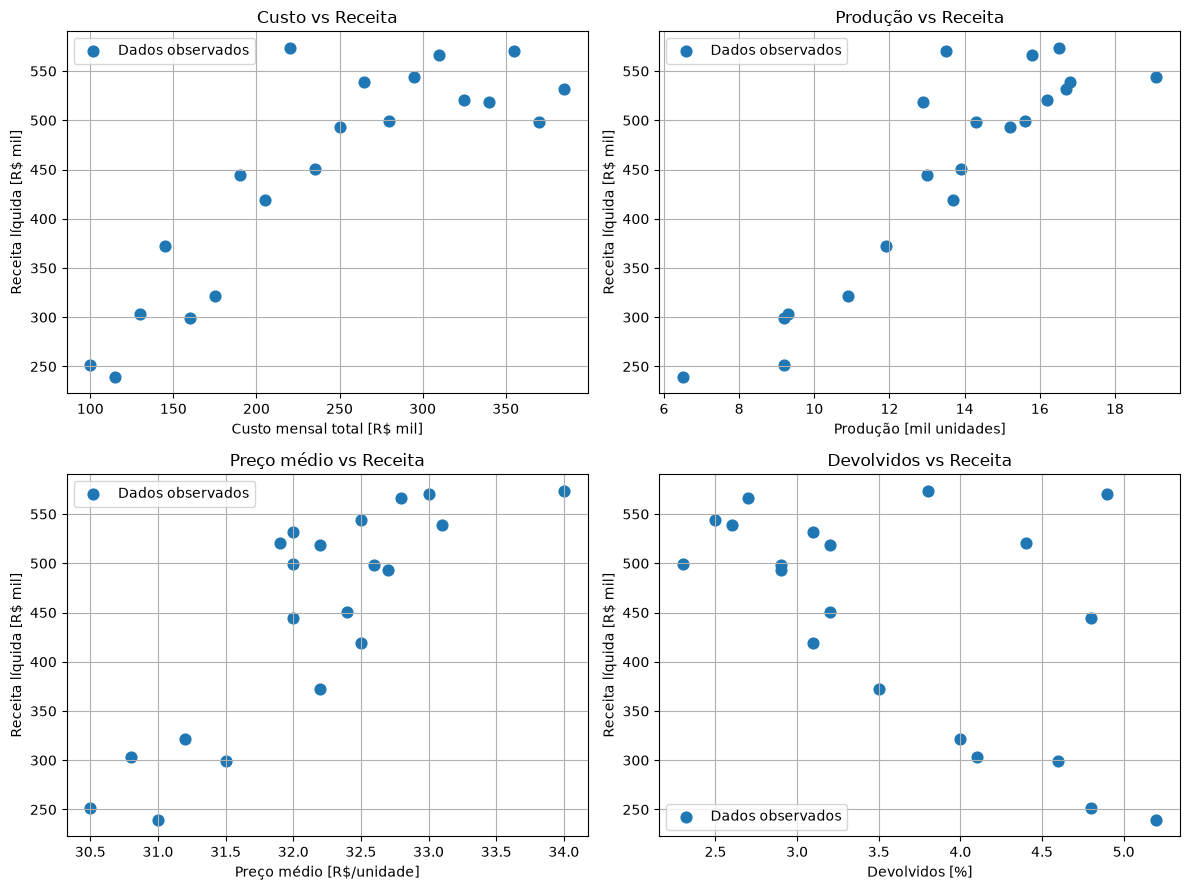

In [ ]:
# Visualização dos dados

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# ==========================================================
# 1. Custo vs Receita
# ==========================================================

axes[0, 0].scatter(
    x1,
    y,
    s=60,
    label="Dados observados"
)

axes[0, 0].set_xlabel("Custo mensal total [R$ mil]")
axes[0, 0].set_ylabel("Receita líquida [R$ mil]")
axes[0, 0].set_title("Custo vs Receita")
axes[0, 0].grid(True)
axes[0, 0].legend()


# ==========================================================
# 2. Produção vs Receita
# ==========================================================

axes[0, 1].scatter(
    x2,
    y,
    s=60,
    label="Dados observados"
)

axes[0, 1].set_xlabel("Produção [mil unidades]")
axes[0, 1].set_ylabel("Receita líquida [R$ mil]")
axes[0, 1].set_title("Produção vs Receita")
axes[0, 1].grid(True)
axes[0, 1].legend()


# ==========================================================
# 3. Preço médio vs Receita
# ==========================================================

axes[1, 0].scatter(
    x3,
    y,
    s=60,
    label="Dados observados"
)

axes[1, 0].set_xlabel("Preço médio [R$/unidade]")
axes[1, 0].set_ylabel("Receita líquida [R$ mil]")
axes[1, 0].set_title("Preço médio vs Receita")
axes[1, 0].grid(True)
axes[1, 0].legend()


# ==========================================================
# 4. Demanda vs Receita
# ==========================================================

axes[1, 1].scatter(
    x4,
    y,
    s=60,
    label="Dados observados"
)

axes[1, 1].set_xlabel("Devolvidos [%]")
axes[1, 1].set_ylabel("Receita líquida [R$ mil]")
axes[1, 1].set_title("Devolvidos vs Receita")
axes[1, 1].grid(True)
axes[1, 1].legend()


# Ajusta o espaçamento entre os gráficos
plt.tight_layout()

plt.show()

In [ ]:
# Preparação dos dados

X_todos = np.column_stack([
    x1,
    x2,
    x3,
    x4
])
y_sklearn = y

print("Formato de X:", X_todos.shape)
print("Formato de y:", y_sklearn.shape)

Formato de X: (20, 4)
Formato de y: (20,)


## Modelo com uma única característica

Primeiro treinaremos um modelo que possui apenas o custo total mensal de operação como sendo a característica de entrada. Portanto, treinaremos o modelo

$$
\hat{y}=w_1x_1+b.
$$

=== Scikit-Learn ===
w = 1.068193
b = 188.873702
MSE = 3189.246096


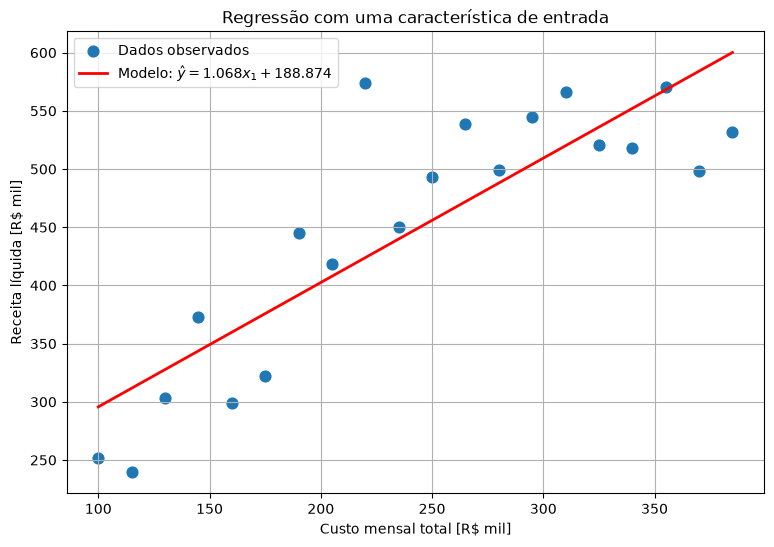

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error


# ==========================================================
# Preparação dos dados
# ==========================================================

X_sklearn = x1.reshape(-1, 1)

# ==========================================================
# Modelo com apenas uma característica de entrada: x1
# ==========================================================

modelo_sklearn = MLPRegressor(
    hidden_layer_sizes=(),
    activation="identity",
    solver="lbfgs",
    random_state=42,
    max_iter=5000
)

modelo_sklearn.fit(X_sklearn, y)

# ==========================================================
# Extraindo os parâmetros aprendidos
# ==========================================================

w_sklearn = modelo_sklearn.coefs_[0][0, 0]
b_sklearn = modelo_sklearn.intercepts_[0][0]

# ==========================================================
# Previsões
# ==========================================================

y_pred_sklearn = modelo_sklearn.predict(X_sklearn)

# ==========================================================
# Cálculo do MSE
# ==========================================================

mse_sklearn = mean_squared_error(y, y_pred_sklearn)

# ==========================================================
# Resultados
# ==========================================================

print("=== Scikit-Learn ===")
print(f"w = {w_sklearn:.6f}")
print(f"b = {b_sklearn:.6f}")
print(f"MSE = {mse_sklearn:.6f}")

# ==========================================================
# Gráfico
# ==========================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    x1,
    y,
    s=60,
    label="Dados observados"
)

# Ordenando x1 para desenhar corretamente a reta
indices = np.argsort(x1)

plt.plot(
    x1[indices],
    y_pred_sklearn[indices],
    color="red",
    linewidth=2,
    label=rf"Modelo: $\hat{{y}} = {w_sklearn:.3f}x_1 + {b_sklearn:.3f}$"
)

plt.xlabel("Custo mensal total [R$ mil]")
plt.ylabel("Receita líquida [R$ mil]")
plt.title("Regressão com uma característica de entrada")
plt.grid(True)
plt.legend()

plt.show()

y_modelo1 = y_pred_sklearn # Será usado depois para realizar mais comparações

## Modelo com uma característica real e outra artificialmente criada

Agora treinaremos um modelo que possui as seguintes características:

- $x_1$: custo total mensal de operação

- $x_2$: $\sqrt{x_1}$

Portanto, treinaremos um modelo com a seguinte estrutura:

$$
\hat{y}=w_1x_1+w_2\sqrt{x_1}+b.
$$

<>:86: SyntaxWarning: invalid escape sequence '\s'
<>:86: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Ricardo\AppData\Local\Temp\ipykernel_3372\1536894038.py:86: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Regressão com $x_1$ e $\sqrt{x_1}$")


=== Scikit-Learn ===
w1 = -3.926918
w2 = 150.652452
b  = -905.395977
MSE = 1754.143349


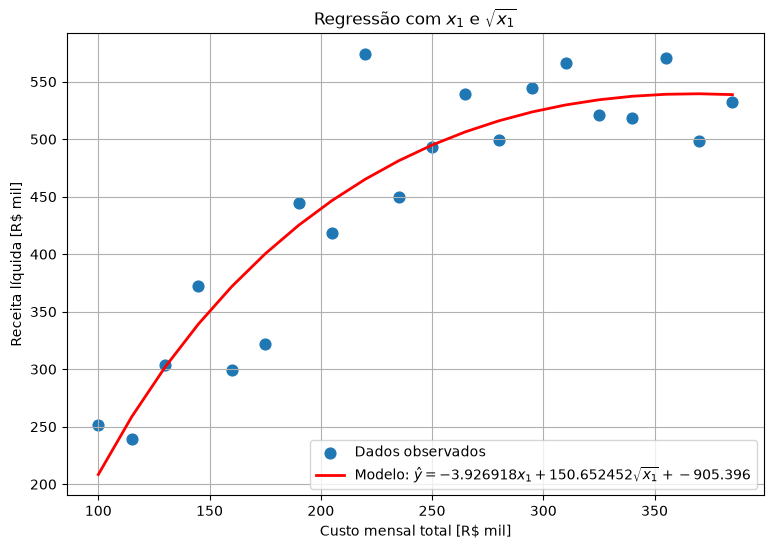

In [ ]:

# ==========================================================
# Preparação dos dados
# ==========================================================

X_sklearn = np.column_stack([
    x1,
    np.sqrt(x1)
])

# ==========================================================
# Modelo com duas características de entrada: x1 e sqrt(x1)
# ==========================================================

modelo_sklearn = MLPRegressor(
    hidden_layer_sizes=(),
    activation="identity",
    solver="lbfgs",
    random_state=42,
    max_iter=5000
)

modelo_sklearn.fit(X_sklearn, y)

# ==========================================================
# Extraindo os parâmetros aprendidos
# ==========================================================

w1_sklearn = modelo_sklearn.coefs_[0][0, 0]
w2_sklearn = modelo_sklearn.coefs_[0][1, 0]

b_sklearn = modelo_sklearn.intercepts_[0][0]

# ==========================================================
# Previsões
# ==========================================================

y_pred_sklearn = modelo_sklearn.predict(X_sklearn)

# ==========================================================
# Cálculo do MSE
# ==========================================================

mse_sklearn = mean_squared_error(y, y_pred_sklearn)

# ==========================================================
# Resultados
# ==========================================================

print("=== Scikit-Learn ===")
print(f"w1 = {w1_sklearn:.6f}")
print(f"w2 = {w2_sklearn:.6f}")
print(f"b  = {b_sklearn:.6f}")
print(f"MSE = {mse_sklearn:.6f}")

# ==========================================================
# Gráfico
# ==========================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    x1,
    y,
    s=60,
    label="Dados observados"
)

# Ordenando x1 para desenhar corretamente a curva
indices = np.argsort(x1)

plt.plot(
    x1[indices],
    y_pred_sklearn[indices],
    color="red",
    linewidth=2,
    label=(
        rf"Modelo: $\hat{{y}} = "
        rf"{w1_sklearn:.6f}x_1 "
        rf"+ {w2_sklearn:.6f}\sqrt{{x_1}} "
        rf"+ {b_sklearn:.3f}$"
    )
)

plt.xlabel("Custo mensal total [R$ mil]")
plt.ylabel("Receita líquida [R$ mil]")
plt.title("Regressão com $x_1$ e $\sqrt{x_1}$")
plt.grid(True)
plt.legend()

plt.show()

y_modelo2 = y_pred_sklearn # Será usado depois para realizar mais comparações

## Modelo com as quatro características disponíveis

Agora treinaremos um modelo que possui as quatro características disponíveis no banco de dados.

Portanto, treinaremos um modelo com a seguinte estrutura:

$$
\hat{y}=w_1x_1+w_2x_2+w_3x_3+w_4x_4+b.
$$

=== Scikit-Learn ===
w1 = 0.493060
w2 = 14.560423
w3 = 47.585120
w4 = 12.276639
b  = -1442.555732
MSE = 396.685918


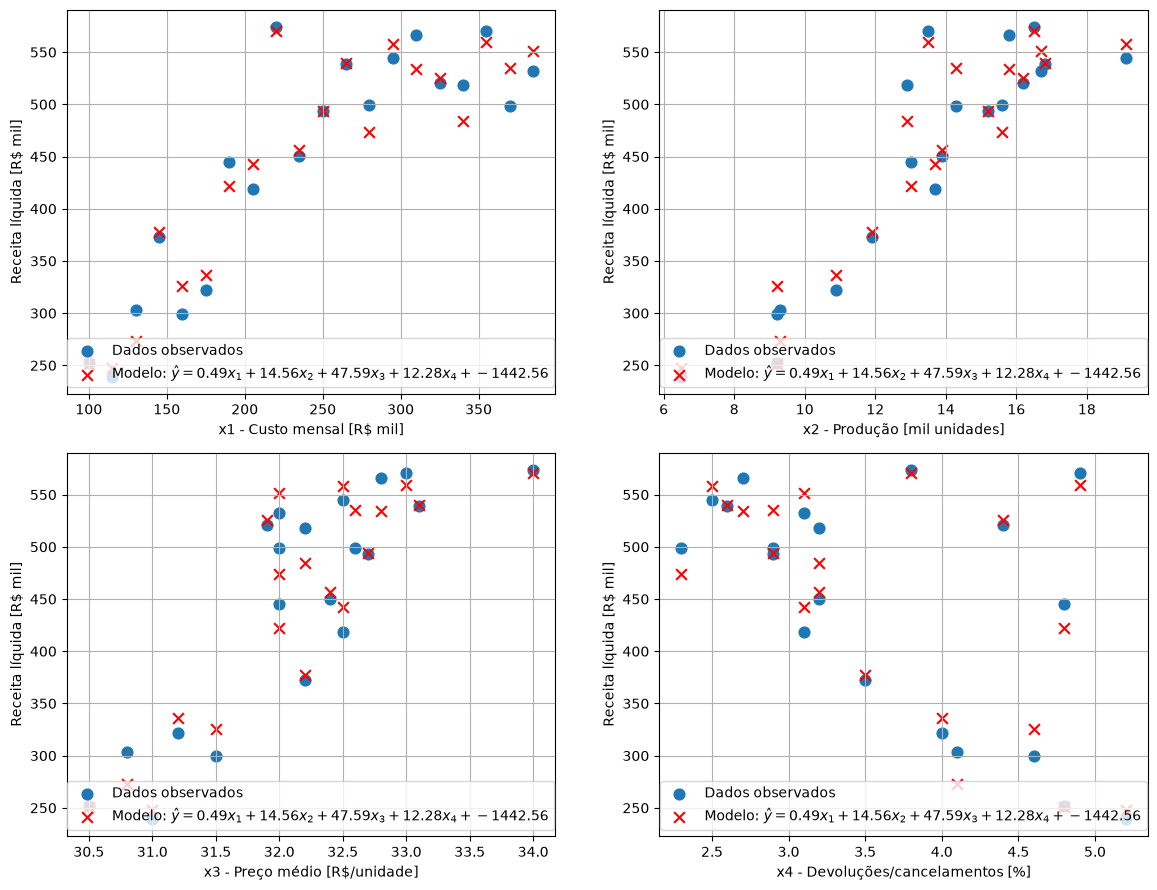

In [ ]:

# ==========================================================
# Preparação dos dados
# ==========================================================

X_sklearn = np.column_stack([
    x1,
    x2,
    x3,
    x4
])

# ==========================================================
# Modelo com quatro características de entrada
# ==========================================================

modelo_sklearn = MLPRegressor(
    hidden_layer_sizes=(),
    activation="identity",
    solver="lbfgs",
    random_state=42,
    max_iter=5000
)

modelo_sklearn.fit(X_sklearn, y)

# ==========================================================
# Extraindo os parâmetros aprendidos
# ==========================================================

w1_sklearn = modelo_sklearn.coefs_[0][0, 0]
w2_sklearn = modelo_sklearn.coefs_[0][1, 0]
w3_sklearn = modelo_sklearn.coefs_[0][2, 0]
w4_sklearn = modelo_sklearn.coefs_[0][3, 0]

b_sklearn = modelo_sklearn.intercepts_[0][0]

# ==========================================================
# Previsões
# ==========================================================

y_pred_sklearn = modelo_sklearn.predict(X_sklearn)

# ==========================================================
# Cálculo do MSE
# ==========================================================

mse_sklearn = mean_squared_error(y, y_pred_sklearn)

# ==========================================================
# Resultados
# ==========================================================

print("=== Scikit-Learn ===")
print(f"w1 = {w1_sklearn:.6f}")
print(f"w2 = {w2_sklearn:.6f}")
print(f"w3 = {w3_sklearn:.6f}")
print(f"w4 = {w4_sklearn:.6f}")
print(f"b  = {b_sklearn:.6f}")
print(f"MSE = {mse_sklearn:.6f}")

# ==========================================================
# Gráficos
# ==========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# ==========================================================
# x1 vs y
# ==========================================================

axes[0, 0].scatter(
    x1,
    y,
    s=60,
    label="Dados observados"
)

axes[0, 0].scatter(
    x1,
    y_pred_sklearn,
    s=60,
    marker="x",
    color="red",
    label=(
        rf"Modelo: $\hat{{y}} = "
        rf"{w1_sklearn:.2f}x_1 "
        rf"+ {w2_sklearn:.2f}x_2 "
        rf"+ {w3_sklearn:.2f}x_3 "
        rf"+ {w4_sklearn:.2f}x_4 "
        rf"+ {b_sklearn:.2f}$"
    )
)

axes[0, 0].set_xlabel("x1 - Custo mensal [R$ mil]")
axes[0, 0].set_ylabel("Receita líquida [R$ mil]")
axes[0, 0].grid(True)
axes[0, 0].legend(loc="lower center")


# ==========================================================
# x2 vs y
# ==========================================================

axes[0, 1].scatter(
    x2,
    y,
    s=60,
    label="Dados observados"
)

axes[0, 1].scatter(
    x2,
    y_pred_sklearn,
    s=60,
    marker="x",
    color="red",
    label=(
        rf"Modelo: $\hat{{y}} = "
        rf"{w1_sklearn:.2f}x_1 "
        rf"+ {w2_sklearn:.2f}x_2 "
        rf"+ {w3_sklearn:.2f}x_3 "
        rf"+ {w4_sklearn:.2f}x_4 "
        rf"+ {b_sklearn:.2f}$"
    )
)

axes[0, 1].set_xlabel("x2 - Produção [mil unidades]")
axes[0, 1].set_ylabel("Receita líquida [R$ mil]")
axes[0, 1].grid(True)
axes[0, 1].legend(loc="lower center")


# ==========================================================
# x3 vs y
# ==========================================================

axes[1, 0].scatter(
    x3,
    y,
    s=60,
    label="Dados observados"
)

axes[1, 0].scatter(
    x3,
    y_pred_sklearn,
    s=60,
    marker="x",
    color="red",
    label=(
        rf"Modelo: $\hat{{y}} = "
        rf"{w1_sklearn:.2f}x_1 "
        rf"+ {w2_sklearn:.2f}x_2 "
        rf"+ {w3_sklearn:.2f}x_3 "
        rf"+ {w4_sklearn:.2f}x_4 "
        rf"+ {b_sklearn:.2f}$"
    )
)

axes[1, 0].set_xlabel("x3 - Preço médio [R$/unidade]")
axes[1, 0].set_ylabel("Receita líquida [R$ mil]")
axes[1, 0].grid(True)
axes[1, 0].legend(loc="lower center")


# ==========================================================
# x4 vs y
# ==========================================================

axes[1, 1].scatter(
    x4,
    y,
    s=60,
    label="Dados observados"
)

axes[1, 1].scatter(
    x4,
    y_pred_sklearn,
    s=60,
    marker="x",
    color="red",
    label=(
        rf"Modelo: $\hat{{y}} = "
        rf"{w1_sklearn:.2f}x_1 "
        rf"+ {w2_sklearn:.2f}x_2 "
        rf"+ {w3_sklearn:.2f}x_3 "
        rf"+ {w4_sklearn:.2f}x_4 "
        rf"+ {b_sklearn:.2f}$"
    )
)

axes[1, 1].set_xlabel("x4 - Devoluções/cancelamentos [%]")
axes[1, 1].set_ylabel("Receita líquida [R$ mil]")
axes[1, 1].grid(True)
axes[1, 1].legend(loc="lower center")


# ==========================================================
# Ajustes finais
# ==========================================================

plt.tight_layout()
plt.show()

y_modelo3 = y_pred_sklearn # Será usado depois para realizar mais comparações

Abaixo comparamos os três modelos num único gráfico

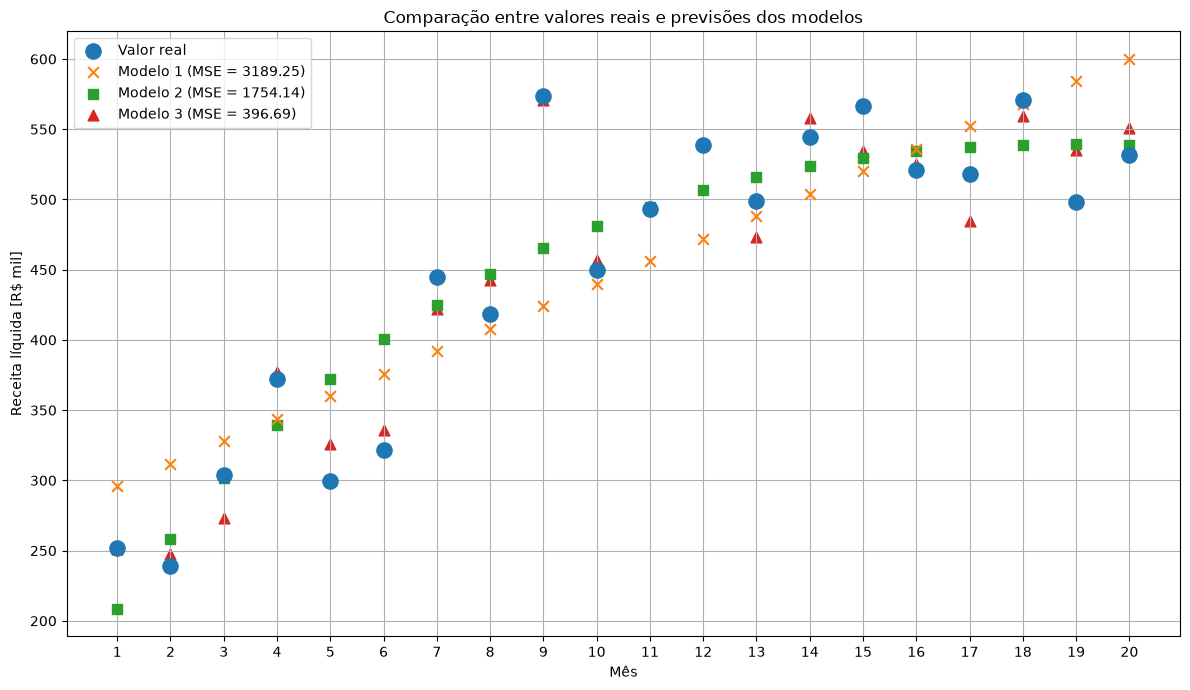

In [ ]:
# ==========================================================
# Mês das amostras
# ==========================================================

meses = np.arange(1, 21)

# ==========================================================
# Cálculo dos MSEs
# ==========================================================

mse_modelo1 = mean_squared_error(y, y_modelo1)
mse_modelo2 = mean_squared_error(y, y_modelo2)
mse_modelo3 = mean_squared_error(y, y_modelo3)

# ==========================================================
# Gráfico
# ==========================================================

plt.figure(figsize=(12, 7))

# Valores reais
plt.scatter(
    meses,
    y,
    s=120,
    marker="o",
    label="Valor real",
    zorder=4
)

# Modelo 1
plt.scatter(
    meses,
    y_modelo1,
    s=60,
    marker="x",
    label=f"Modelo 1 (MSE = {mse_modelo1:.2f})",
    zorder=3
)

# Modelo 2
plt.scatter(
    meses,
    y_modelo2,
    s=60,
    marker="s",
    label=f"Modelo 2 (MSE = {mse_modelo2:.2f})",
    zorder=2
)

# Modelo 3
plt.scatter(
    meses,
    y_modelo3,
    s=60,
    marker="^",
    label=f"Modelo 3 (MSE = {mse_modelo3:.2f})",
    zorder=1
)

# ==========================================================
# Configurações
# ==========================================================

plt.xlabel("Mês")
plt.ylabel("Receita líquida [R$ mil]")
plt.title("Comparação entre valores reais e previsões dos modelos")

plt.xticks(meses)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Métricas de avaliação de modelos

Para comparar o desempenho dos três modelos de regressão, serão utilizadas cinco métricas: **MSE, RMSE, $R^2$, MAPE e sMAPE**. Cada uma delas fornece uma perspectiva diferente sobre a qualidade das previsões.

### MSE — Mean Squared Error

O **Erro Quadrático Médio (MSE)** calcula a média dos quadrados dos erros entre os valores reais e os valores previstos:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

O MSE penaliza fortemente erros grandes, pois os erros são elevados ao quadrado. **Quanto menor o MSE, melhor o modelo.**

A unidade do MSE é o quadrado da unidade da variável de saída. Neste caso, como a receita está em R$ mil, o MSE está em $(R\$\,mil)^2$.

---

### RMSE — Root Mean Squared Error

O **Erro Quadrático Médio da Raiz (RMSE)** é simplesmente a raiz quadrada do MSE:

$$
RMSE = \sqrt{MSE}
$$

Uma vantagem do RMSE é que ele possui a **mesma unidade da variável que está sendo prevista**. Neste caso, o RMSE é expresso em R$ mil.

Assim como no MSE, **quanto menor o RMSE, melhor o modelo**.

---

### $R^2$ — Coeficiente de Determinação

O **coeficiente de determinação ($R^2$)** indica quanto da variabilidade observada na variável de saída é explicada pelo modelo:

$$
R^2 =
1 -
\frac{
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
}{
\sum_{i=1}^{n}(y_i-\bar{y})^2
}
$$

Em geral, valores próximos de 1 indicam que o modelo consegue explicar uma grande parte da variação dos dados.

Para esta comparação, **quanto maior o $R^2$, melhor o modelo**.

Um $R^2$ próximo de 0 indica que o modelo apresenta pouca capacidade de explicar a variabilidade dos dados em comparação com simplesmente utilizar a média das observações. Valores negativos também podem ocorrer quando o modelo apresenta desempenho pior do que essa referência.

---

### MAPE — Mean Absolute Percentage Error

O **Erro Percentual Absoluto Médio (MAPE)** mede o erro médio das previsões em termos percentuais:

$$
MAPE =
\frac{100}{n}
\sum_{i=1}^{n}
\left|
\frac{y_i-\hat{y}_i}{y_i}
\right|
$$

Essa métrica facilita a interpretação porque indica, aproximadamente, o tamanho médio do erro em relação ao valor real.

Por exemplo, um MAPE de $5\%$ indica que o erro percentual absoluto médio das previsões foi de aproximadamente 5%.

**Quanto menor o MAPE, melhor o modelo.**

---

### sMAPE — Symmetric Mean Absolute Percentage Error

O **sMAPE** é uma alternativa ao MAPE que utiliza tanto o valor real quanto o valor previsto no denominador:

$$
sMAPE =
\frac{100}{n}
\sum_{i=1}^{n}
\frac{
2|y_i-\hat{y}_i|
}{
|y_i|+|\hat{y}_i|
}
$$

Essa formulação torna a métrica mais simétrica em relação aos valores real e previsto.

Assim como o MAPE, o sMAPE é expresso em porcentagem e **quanto menor o valor, melhor o modelo**.

---

### Comparação das métricas

As cinco métricas podem ser resumidas da seguinte forma:

| Métrica | O que mede | Melhor resultado |
|---|---|---|
| **MSE** | Erro quadrático médio | Menor |
| **RMSE** | Erro médio na mesma unidade da saída | Menor |
| **$R^2$** | Capacidade de explicar a variabilidade dos dados | Maior |
| **MAPE** | Erro percentual absoluto médio | Menor |
| **sMAPE** | Erro percentual simétrico médio | Menor |

É importante observar que **não existe necessariamente uma única métrica que seja suficiente para avaliar um modelo**. Por isso, nesta atividade, utilizaremos as cinco métricas em conjunto para comparar os três modelos e identificar seus pontos fortes e fracos.

Ao final, será indicado, para cada métrica, qual dos três modelos apresentou o melhor desempenho.


In [ ]:

from sklearn.metrics import mean_squared_error, r2_score

# ==========================================================
# Funções para as métricas
# ==========================================================

def calcular_mape(y_real, y_pred):
    return np.mean(np.abs((y_real - y_pred) / y_real)) * 100


def calcular_smape(y_real, y_pred):
    return np.mean(
        2 * np.abs(y_pred - y_real) /
        (np.abs(y_real) + np.abs(y_pred))
    ) * 100


# ==========================================================
# Modelos
# ==========================================================

modelos = {
    "Modelo 1": y_modelo1,
    "Modelo 2": y_modelo2,
    "Modelo 3": y_modelo3
}

# ==========================================================
# Cálculo das métricas
# ==========================================================

resultados = []

for nome, y_pred in modelos.items():

    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    mape = calcular_mape(y, y_pred)
    smape = calcular_smape(y, y_pred)

    resultados.append([
        nome,
        mse,
        rmse,
        r2,
        mape,
        smape
    ])

# ==========================================================
# Criando a tabela
# ==========================================================

tabela_metricas = pd.DataFrame(
    resultados,
    columns=[
        "Modelo",
        "MSE",
        "RMSE",
        "R²",
        "MAPE [%]",
        "sMAPE [%]"
    ]
)

# ==========================================================
# Determinando o modelo vencedor em cada métrica
# ==========================================================

vencedores = {
    "MSE": tabela_metricas.loc[tabela_metricas["MSE"].idxmin(), "Modelo"],
    "RMSE": tabela_metricas.loc[tabela_metricas["RMSE"].idxmin(), "Modelo"],
    "R²": tabela_metricas.loc[tabela_metricas["R²"].idxmax(), "Modelo"],
    "MAPE [%]": tabela_metricas.loc[tabela_metricas["MAPE [%]"].idxmin(), "Modelo"],
    "sMAPE [%]": tabela_metricas.loc[tabela_metricas["sMAPE [%]"].idxmin(), "Modelo"]
}

# ==========================================================
# Adicionando a linha "Vencedor"
# ==========================================================

linha_vencedor = {
    "Modelo": "Vencedor",
    "MSE": vencedores["MSE"],
    "RMSE": vencedores["RMSE"],
    "R²": vencedores["R²"],
    "MAPE [%]": vencedores["MAPE [%]"],
    "sMAPE [%]": vencedores["sMAPE [%]"]
}

tabela_metricas = pd.concat(
    [
        tabela_metricas,
        pd.DataFrame([linha_vencedor])
    ],
    ignore_index=True
)

# ==========================================================
# Exibindo a tabela
# ==========================================================

tabela_metricas

,Modelo,MSE,RMSE,R²,MAPE [%],sMAPE [%]
0,Modelo 1,3189.246096,56.473411,0.728011,11.049273,10.830482
1,Modelo 2,1754.143349,41.882495,0.850401,8.080734,7.992235
2,Modelo 3,396.685918,19.916976,0.966169,3.756143,3.763253
3,Vencedor,Modelo 3,Modelo 3,Modelo 3,Modelo 3,Modelo 3


## Conclusões e questões para discussão

Neste experimento, utilizamos uma **rede neural com apenas um neurônio** para prever a receita líquida de uma indústria a partir de diferentes conjuntos de características.

Inicialmente, consideramos apenas o **custo mensal total de operação** como característica de entrada. Em seguida, utilizamos uma transformação desse custo, como $x_1^2$ ou $\sqrt{x_1}$, para verificar se uma nova característica poderia melhorar a capacidade de representação do modelo.

Por fim, utilizamos simultaneamente as quatro características disponíveis:

$$
x_1 = \text{custo mensal total}
$$

$$
x_2 = \text{produção}
$$

$$
x_3 = \text{preço médio de venda}
$$

$$
x_4 = \text{devoluções/cancelamentos}
$$

Nesse último caso, o neurônio implementa o modelo:

$$
\hat{y}
=
w_1x_1+w_2x_2+w_3x_3+w_4x_4+b
$$

Os diferentes modelos foram comparados utilizando **MSE, RMSE, MAE, MedAE, $R^2$, MAPE e sMAPE**. A análise dessas métricas permite observar como a inclusão de características adicionais pode afetar a qualidade das previsões.

### Questões para discussão

1. O que representa o valor de cada peso $w_i$ no modelo?

2. O que significa o valor de $b$ neste problema?

3. Por que a inclusão de características adicionais pode melhorar a previsão da receita líquida?

4. Uma característica apresentar correlação com a receita significa necessariamente que ela é a causa dessa variação?

5. Por que diferentes métricas podem indicar desempenhos diferentes para os modelos?

6. Seria razoável utilizar esses modelos para prever a receita de uma indústria em condições muito diferentes das observadas nos 20 meses utilizados no treinamento?

### Uma observação importante

Este exemplo é propositalmente simplificado. O objetivo não é construir um modelo financeiro realista, mas demonstrar como uma **rede neural com um único neurônio e ativação linear pode ser utilizada para realizar regressão**.

Mesmo quando utilizamos várias características de entrada, o modelo continua sendo linear nos parâmetros:

$$
\hat{y}
=
w_1x_1+w_2x_2+\cdots+w_nx_n+b
$$

Portanto, uma rede neural com **um único neurônio, sem camadas ocultas e com ativação linear**, é matematicamente equivalente a um modelo de **regressão linear múltipla**.

Para problemas mais complexos, nos quais existam relações não lineares entre as características e a variável de saída, podem ser utilizadas arquiteturas com **camadas ocultas e funções de ativação não lineares**. Nesses casos, ferramentas como o **TensorFlow/Keras** tornam-se especialmente úteis para construir e treinar redes neurais mais complexas.